# Partie 2 — Deep Learning Fondamental
## Jalon 5 : Architecture (MLP vs CNN vs RNN)
**Auteur : Hedi MATHLOUTHI**

In [13]:
import sys
import importlib

sys.path.insert(0, '../src')

import torch
import dataset
import models
import training
import utils

importlib.reload(dataset)
importlib.reload(models)
importlib.reload(training)
importlib.reload(utils)

from dataset import ensure_dl_full_data, create_dataloaders, get_class_weights
from models import EmotionMLP, EmotionCNN, describe_architecture, count_parameters
from training import set_seed, get_device, train_model

set_seed(42)
device = get_device()
print(f'Device : {device}')
print(f'train_model early_stop : {"early_stop_patience" in str(training.train_model.__code__.co_varnames)}')
print('Imports OK')

Device : cpu
train_model early_stop : True
Imports OK


### 1. Chargement des données (Partie 1)

In [14]:
# Dataset complet Partie 2 (n'écrase pas data.pkl de la Partie 1)
data = ensure_dl_full_data('../data/processed/data_dl_full.pkl')
print(f"X_train : {data['X_train'].shape}")
print(f"X_test  : {data['X_test'].shape}")
class_weights = get_class_weights(data['y_train'])
print(f'Poids des classes : {class_weights.numpy().round(2)}')

Partie 2 : chargement ../data/processed/data_dl_full.pkl (28709 train)
X_train : (28709, 2304)
X_test  : (7178, 2304)
Poids des classes : [1.03 9.41 1.   0.57 0.85 1.29 0.83]


### 2. Justification du choix d'architecture

| Architecture | Pertinence FER2013 | Verdict |
|--------------|-------------------|--------|
| **RNN/LSTM** | Conçu pour séquences temporelles ; une image est un instantané spatial | ❌ Non adapté |
| **MLP** | Traite les pixels comme un vecteur ; ignore la structure 2D (yeux, bouche) | ⚠️ Référence DL |
| **CNN** | Filtres convolutifs = détection de motifs locaux (sourcils, sourire) | ✅ **Choix principal** |

La Partie 1 a montré ~30% avec Ridge sur pixels aplatis + PCA : le ML classique ne capture pas la **spatialité**.
Le CNN réintroduit cette inductive bias via convolutions + pooling.

### 3. Architecture MLP (référence)

In [15]:
mlp = EmotionMLP(dropout=0.5)
describe_architecture(mlp, 'EmotionMLP')

train_loader_mlp, test_loader_mlp = create_dataloaders(
    data, batch_size=64, mode='flat'
)


Architecture : EmotionMLP
EmotionMLP(
  (network): Sequential(
    (0): Linear(in_features=2304, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=7, bias=True)
  )
)

Paramètres entraînables : 1,314,823


### 4. Architecture CNN (modèle principal)

In [16]:
cnn = EmotionCNN(dropout=0.5)
describe_architecture(cnn, 'EmotionCNN')

train_loader, test_loader = create_dataloaders(
    data, batch_size=64, mode='image'
)


Architecture : EmotionCNN
EmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_di

### 5. Stratégie anti Vanishing / Exploding Gradient

- **ReLU** : évite la saturation de sigmoid/tanh (gradient → 0)
- **BatchNorm** : stabilise les activations, accélère la convergence
- **Gradient clipping** (`max_norm=1.0`) : borne les gradients extrêmes
- **Dropout** : régularisation, limite le surapprentissage
- **Poids de classes** : compense le déséquilibre (Disgust vs Happy)

### 6. Entraînement initial du CNN (15 epochs)

Epoch 01/25 | train_loss=1.7715 acc=31.43% | test_acc=42.30%


Epoch 02/25 | train_loss=1.5040 acc=43.38% | test_acc=47.76%


Epoch 03/25 | train_loss=1.4084 acc=47.61% | test_acc=51.11%


Epoch 04/25 | train_loss=1.3523 acc=49.20% | test_acc=51.99%


Epoch 05/25 | train_loss=1.3133 acc=50.86% | test_acc=53.62%


...

Epoch 21/25 | train_loss=0.8571 acc=66.87% | test_acc=61.59%


Epoch 22/25 | train_loss=0.8457 acc=67.54% | test_acc=62.37%


Epoch 23/25 | train_loss=0.7687 acc=69.72% | test_acc=64.63%


Epoch 24/25 | train_loss=0.7277 acc=71.26% | test_acc=64.28%


Epoch 25/25 | train_loss=0.7092 acc=72.44% | test_acc=63.68%

Meilleure accuracy test : 64.63%
Temps d'entraînement : 1863.1s
Figure sauvegardée : figures/cnn_training_initial.png


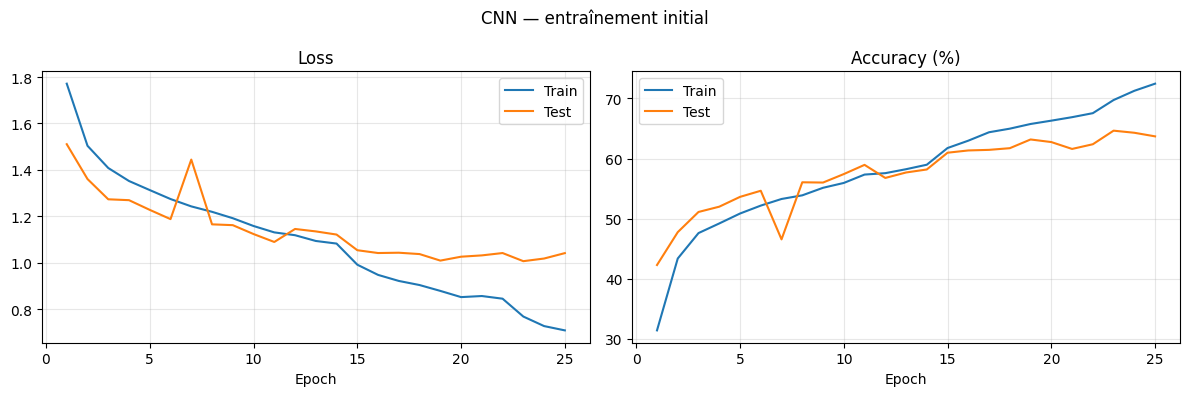

In [17]:
from utils import plot_training_history, save_figure

result_cnn = train_model(
    cnn,
    train_loader,
    test_loader,
    epochs=25,
    lr=1e-3,
    optimizer_name='adam',
    class_weights=class_weights,
    device=device,
    early_stop_patience=6,
)

print(f"\nMeilleure accuracy test : {result_cnn['best_test_acc']*100:.2f}%")
print(f"Temps d'entraînement : {result_cnn['train_time_sec']:.1f}s")

plot_training_history(result_cnn['history'], 'CNN — entraînement initial')
save_figure('cnn_training_initial.png')
import matplotlib.pyplot as plt
plt.show()

### 7. Entraînement initial du MLP (comparaison)

In [18]:
mlp = EmotionMLP(dropout=0.5).to(device)
result_mlp = train_model(
    mlp,
    train_loader_mlp,
    test_loader_mlp,
    epochs=25,
    lr=1e-3,
    optimizer_name='adam',
    class_weights=class_weights,
    device=device,
    early_stop_patience=6,
)
print(f"MLP accuracy test : {result_mlp['best_test_acc']*100:.2f}%")

Epoch 01/25 | train_loss=1.8872 acc=25.50% | test_acc=27.54%


Epoch 02/25 | train_loss=1.7973 acc=30.37% | test_acc=25.91%


Epoch 03/25 | train_loss=1.7598 acc=31.72% | test_acc=35.23%


Epoch 04/25 | train_loss=1.7380 acc=32.24% | test_acc=29.26%


Epoch 05/25 | train_loss=1.7160 acc=32.56% | test_acc=37.07%


...

Epoch 21/25 | train_loss=1.3573 acc=43.55% | test_acc=41.96%


Epoch 22/25 | train_loss=1.3412 acc=43.76% | test_acc=41.52%


Epoch 23/25 | train_loss=1.3115 acc=44.73% | test_acc=43.69%


Epoch 24/25 | train_loss=1.2962 acc=45.37% | test_acc=43.49%


Epoch 25/25 | train_loss=1.2801 acc=45.99% | test_acc=43.62%
MLP accuracy test : 43.69%


### 8. Sauvegarde des modèles

In [19]:
import os
import pickle

os.makedirs('../data/processed', exist_ok=True)

torch.save(result_cnn['model'].state_dict(), '../data/processed/cnn_initial.pt')
torch.save(result_mlp['model'].state_dict(), '../data/processed/mlp_initial.pt')

with open('../data/processed/dl_initial_results.pkl', 'wb') as f:
    pickle.dump({
        'cnn_acc': result_cnn['best_test_acc'],
        'cnn_time': result_cnn['train_time_sec'],
        'mlp_acc': result_mlp['best_test_acc'],
        'mlp_time': result_mlp['train_time_sec'],
        'cnn_history': result_cnn['history'],
    }, f)
print('Modèles et résultats sauvegardés dans data/processed/')

Modèles et résultats sauvegardés dans data/processed/
